In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

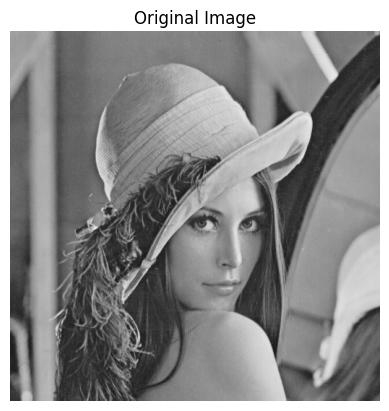

In [ ]:
# load image and convert to RGB
img = Image.open("lena_gray.gif").convert("RGB")

# convert to numpy array
img_array = np.array(img)

# display image
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

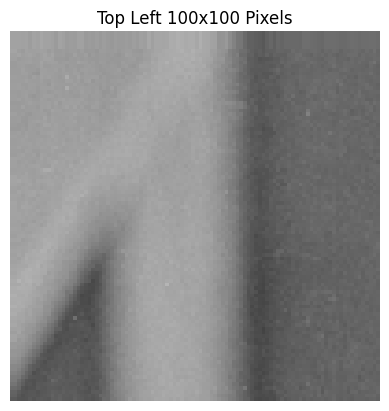

In [ ]:
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

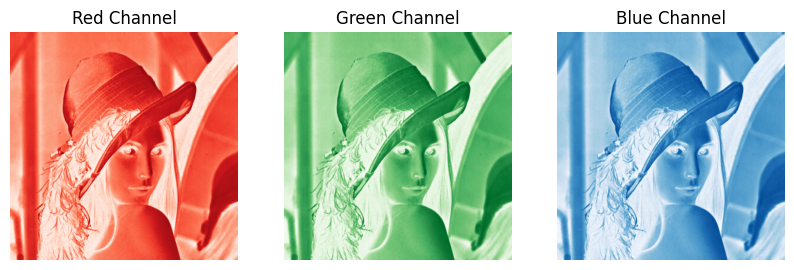

In [ ]:
# separate channels
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

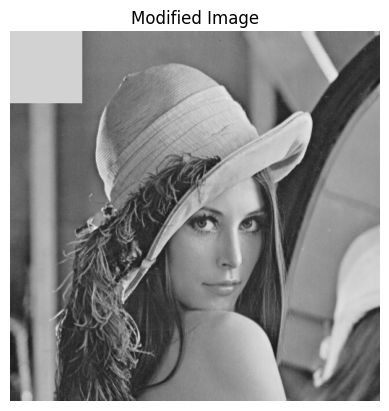

In [ ]:
modified = img_array.copy()

modified[0:100,0:100] = 210

plt.imshow(modified)
plt.title("Modified Image")
plt.axis("off")
plt.show()

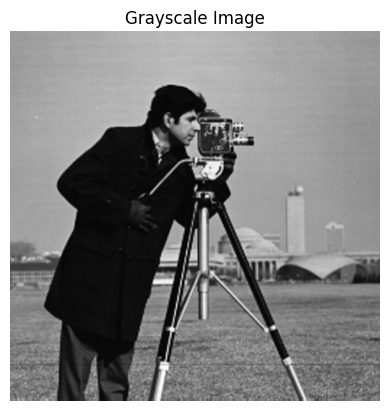

In [ ]:
# load second image
img2 = Image.open("cameraman.png")

# convert to grayscale
gray_img = img2.convert("L")

# convert to numpy array
gray_array = np.array(gray_img)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

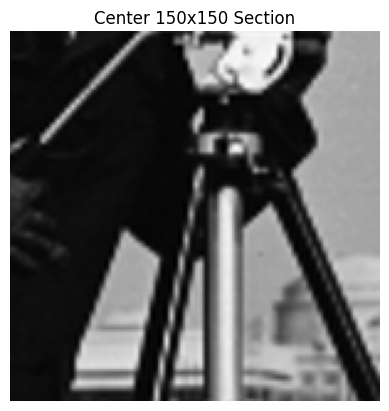

In [ ]:
h, w = gray_array.shape

center = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center, cmap="gray")
plt.title("Center 150x150 Section")
plt.axis("off")
plt.show()

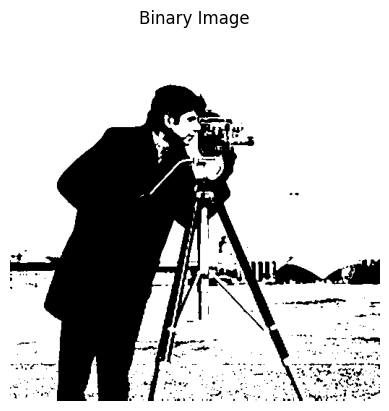

In [ ]:
binary = gray_array.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

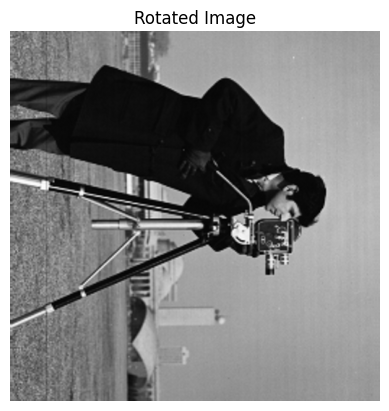

In [ ]:
rotated = gray_img.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")
plt.show()

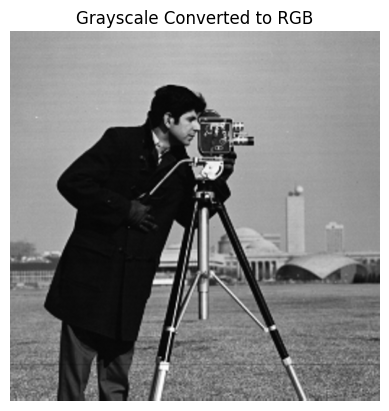

In [ ]:
rgb_img = gray_img.convert("RGB")

plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

Exercise 3

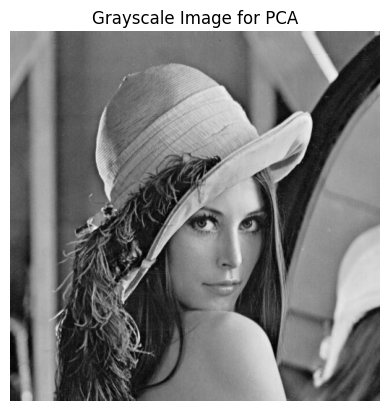

In [ ]:
gray_img = img.convert("L")
gray_array = np.array(gray_img)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image for PCA")
plt.axis("off")
plt.show()

In [ ]:
mean = np.mean(gray_array, axis=0)
centered = gray_array - mean

In [ ]:
cov_matrix = np.cov(centered, rowvar=False)

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [ ]:
sorted_index = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

In [ ]:
k = 50

principal_components = eigenvectors[:, :k]

In [ ]:
compressed = np.dot(centered, principal_components)

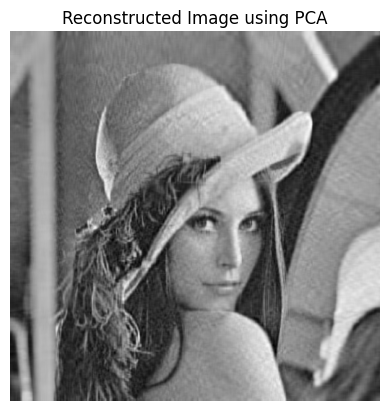

In [ ]:
reconstructed = np.dot(compressed, principal_components.T) + mean
reconstructed = reconstructed.real

plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image using PCA")
plt.axis("off")
plt.show()